Student ID: 2408861

Student Name: Prachi Rajbanshi

In [189]:
# Load Train Data
import os

train_dir = "/content/drive/MyDrive/AIandML/FruitinAmazon/train"
classes = os.listdir(train_dir)
print(classes)

['guarana', 'tucuma', 'pupunha', 'acai', 'cupuacu', 'graviola']


In [190]:
# Load Test Data
import os

test_dir = "/content/drive/MyDrive/AIandML/FruitinAmazon/test"
classes = os.listdir(test_dir)
print(classes)

['tucuma', 'acai', 'guarana', 'graviola', 'pupunha', 'cupuacu']


In [191]:
# Check for Corrupted Images (data)
from PIL import Image, UnidentifiedImageError
corrupted_images =[]

# Loop through each class folder and check for corrupted images
for class_name in classes:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = os.listdir(class_path)
    for image_name in images:
      image_path = os.path.join(class_path, image_name)
      try:
        with Image.open(image_path) as img:
          img.verify()
      except (IOError, UnidentifiedImageError):
        corrupted_images.append(image_path)

# Printing results
if corrupted_images:
  print("Corrupted images found:")
  for image_path in corrupted_images:
    print(image_path)
else:
  print("No corrupted images found.")


No corrupted images found.


In [ ]:
# Dictionary to store class counts
class_counts = {}

for class_name in classes:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[class_name] = len(images) # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
  print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
tucuma                                15
acai                                  15
guarana                               15
graviola                              15
pupunha                               15
cupuacu                               15


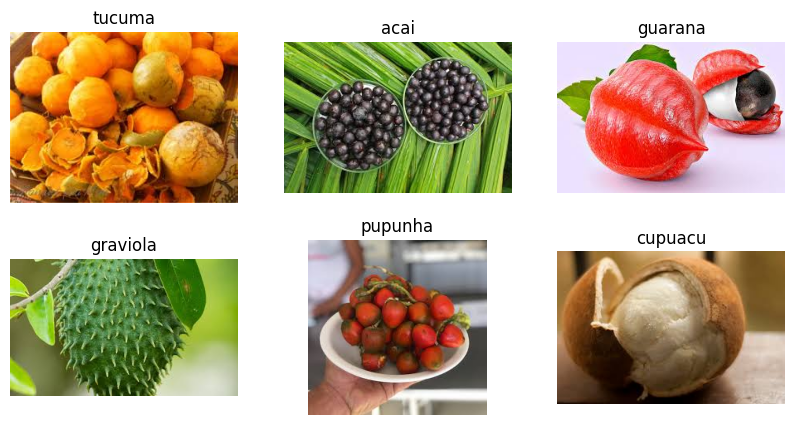

In [ ]:
# Visualize random samples
import matplotlib.pyplot as plt
import random
from PIL import Image

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
  img_path = os.path.join(train_dir, cls, random.choice(os.listdir(os.path.join(train_dir, cls))))
  img = Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img)
  plt.title(cls)
  plt.axis("off")

plt.show()

In [192]:
import tensorflow as tf
from tensorflow import keras

import numpy as np

In [193]:
# Define parameters
image_size = (224, 224)
batch_size = 32
input_shape = (224, 224, 3)

In [194]:
# Load train + validation daatset
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [195]:
# Load test dataset
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [196]:
# Understanding the dataset
for images, labels in train_ds.take(1):
  print("Images shape: ", images.shape) # 23 images, each: height = 28, width = 28, and 1 color channels
  print("Labels shape: ", labels.shape)

Images shape:  (32, 224, 224, 3)
Labels shape:  (32,)


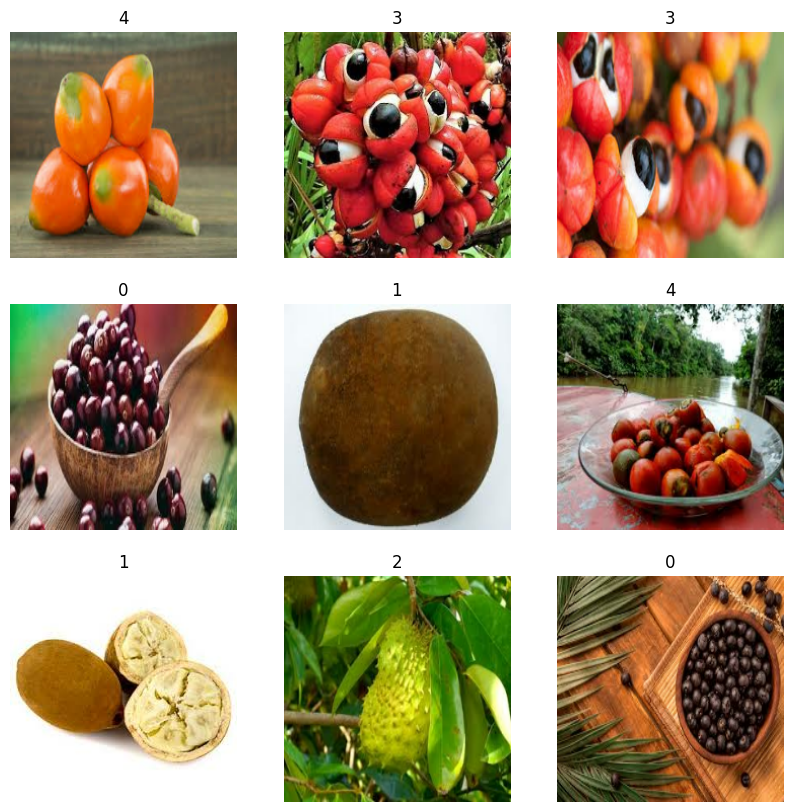

In [197]:
# Visualize the dataset
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1): #Takes one batch of images from the dataset (train_ds).
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(images[i]).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

In [198]:
class_names = train_ds.class_names
num_classes = len(class_names)

In [199]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Activation
layer = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
  beta_initializer="zeros", gamma_initializer="ones")

In [200]:
# DATA AUGMENTATION
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [201]:
# Build Deeper CNN (with BN + DROPOUT)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([

    # Augmentation + Rescaling
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),

    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer
    Dense(len(train_ds.class_names), activation='softmax')
])

In [202]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [203]:
# Model Summary
model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_22 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 50176)          │             

 Total params: 26,216,902 (100.01 MB)

 Trainable params: 26,214,406 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [204]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.2500 - loss: 2.2432 - val_accuracy: 0.1111 - val_loss: 1.8213
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.4444 - loss: 1.5379 - val_accuracy: 0.2222 - val_loss: 1.7694
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step - accuracy: 0.5000 - loss: 1.2703 - val_accuracy: 0.2222 - val_loss: 1.7796
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.4861 - loss: 1.2005 - val_accuracy: 0.2222 - val_loss: 1.9457
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.5556 - loss: 1.1141 - val_accuracy: 0.2222 - val_loss: 2.1419
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.5694 - loss: 1.0664 - val_accuracy: 0.0556 - val_loss: 2.3379
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6250 - loss: 0.8686 - val_accuracy: 0.0556 - val_loss: 2.3894
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.7222 - loss: 0.8480 - val_accuracy: 0.0556 - val_loss: 2.2956
Epoch 9/

In [205]:
# Evaluate Model
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 2.6291
Test Accuracy: 0.1666666716337204


In [206]:
# Predictions
import numpy as np

for images, labels in val_ds.take(1):
    preds = model.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    print("Predicted:", predicted_labels[:5])
    print("Actual:   ", labels[:5].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: [1 1 1 1 1]
Actual:    [4 4 1 5 1]


In [207]:
# Classification report
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in test_ds], axis=0)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.67      0.40      0.50         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.21      1.00      0.34         5
      tucuma       0.33      0.20      0.25         5

    accuracy                           0.27        30
   macro avg       0.20      0.27      0.18        30
weighted avg       0.20      0.27      0.18        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Task 2: Transfer Learning using VGG16**

In [213]:
# Step 1: Load pre-trained VGG16
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

In [214]:
# Step 2: Freeze the Layers
for layer in base_model.layers:
    layer.trainable = False

In [215]:
# Step 3:dd Custom Layers
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [216]:
# Step 4: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [217]:
# Step 5: Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 26s/step - accuracy: 0.3472 - loss: 7.0607 - val_accuracy: 0.2222 - val_loss: 7.1201
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 23s/step - accuracy: 0.6528 - loss: 2.7275 - val_accuracy: 0.5000 - val_loss: 3.0159
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 20s/step - accuracy: 0.7639 - loss: 1.7244 - val_accuracy: 0.5556 - val_loss: 3.9018
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 19s/step - accuracy: 0.8333 - loss: 0.9899 - val_accuracy: 0.6111 - val_loss: 4.2076
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 85s 20s/step - accuracy: 0.9306 - loss: 0.1235 - val_accuracy: 0.5000 - val_loss: 4.4073
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 20s/step - accuracy: 0.9861 - loss: 0.0344 - val_accuracy: 0.5000 - val_loss: 5.5933
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 19s/step - accuracy: 0.9583 - loss: 0.2573 - val_accuracy: 0.5000 - val_loss: 6.2374
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 22s/step - accuracy: 0.9444 - loss: 0.2226 - val_accuracy: 0.5000 - val_loss: 7.0125


In [218]:
# Step 6: Evaluate Model
loss, acc = model.evaluate(val_ds)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.4444 - loss: 6.2988
Test Accuracy: 0.4444444477558136


In [219]:
# Step 7: Predictions
import numpy as np

for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

print("Predicted:", pred_labels[:10])
print("Actual:", labels[:10].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted: [4 2 1 5 2 1 1 3 4 3]
Actual: [4 4 1 5 1 0 1 5 3 0]


In [220]:
# Step 8: Classification report
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.75      0.75      0.75         4
           2       0.25      1.00      0.40         1
           3       0.00      0.00      0.00         1
           4       0.40      0.50      0.44         4
           5       1.00      0.40      0.57         5

    accuracy                           0.44        18
   macro avg       0.40      0.44      0.36        18
weighted avg       0.55      0.44      0.45        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
